In [1]:
import sys
print(sys.executable)


c:\Users\admin\Desktop\Brain_Stroke_Project\stroke_env\Scripts\python.exe


In [2]:
import tensorflow as tf
print(tf.__version__)


2.13.0


In [3]:
import cv2
import os

img_path = os.path.join(
    "../dataset/train/Stroke",
    os.listdir("../dataset/train/Stroke")[0]
)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
print("Image shape:", img.shape)
print("Min pixel:", img.min())
print("Max pixel:", img.max())


Image shape: (650, 650)
Min pixel: 0
Max pixel: 255


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def preprocess_image(img_path, img_size=224):
    # 1. Read grayscale image
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    # 2. Resize
    img = cv2.resize(img, (img_size, img_size))

    # 3. CLAHE (Contrast enhancement)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img = clahe.apply(img)

    # 4. Gaussian blur (noise reduction)
    img = cv2.GaussianBlur(img, (3,3), 0)

    # 5. Normalize
    img = img / 255.0

    return img


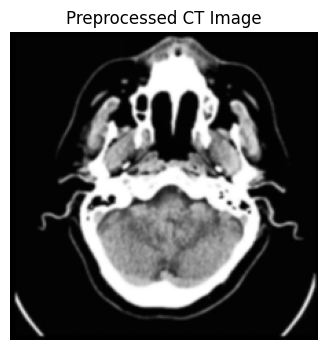

In [5]:
sample_path = "../dataset/train/Stroke/" + \
              os.listdir("../dataset/train/Stroke")[0]

processed = preprocess_image(sample_path)

plt.figure(figsize=(4,4))
plt.imshow(processed, cmap='gray')
plt.axis('off')
plt.title("Preprocessed CT Image")
plt.show()
